In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, ttest_ind, chi2_contingency

In [2]:
#Sample National Achievement Data
data = {
    'Gender': np.random.choice(['Male', 'Female'], 100),
    'School_Type': np.random.choice(['Government', 'Private'], 100),
    'Math_Score': np.random.randint(20, 100, 100),
    'Reading_Score': np.random.randint(20, 100, 100),
    'Science_Score': np.random.randint(20, 100, 100),
    'Study_Hours': np.random.randint(1, 10, 100)
}
df = pd.DataFrame(data)

In [3]:
# Create derived variable
df['High_Achiever'] = np.where(df['Math_Score'] >= 70, 1, 0)

print("Sample Data:\n", df.head())

Sample Data:
    Gender School_Type  Math_Score  Reading_Score  Science_Score  Study_Hours  \
0    Male     Private          44             73             37            4   
1    Male     Private          68             65             90            7   
2  Female     Private          24             44             29            2   
3    Male     Private          52             77             23            1   
4    Male     Private          29             58             78            3   

   High_Achiever  
0              0  
1              0  
2              0  
3              0  
4              0  


In [4]:
#Continuous vs Continuous
print("\n🔹 Continuous vs Continuous (Math vs Reading)")
corr, pval = pearsonr(df['Math_Score'], df['Reading_Score'])
print(f"Pearson Correlation: {corr:.2f}, p-value={pval:.4f}")


🔹 Continuous vs Continuous (Math vs Reading)
Pearson Correlation: 0.11, p-value=0.2896


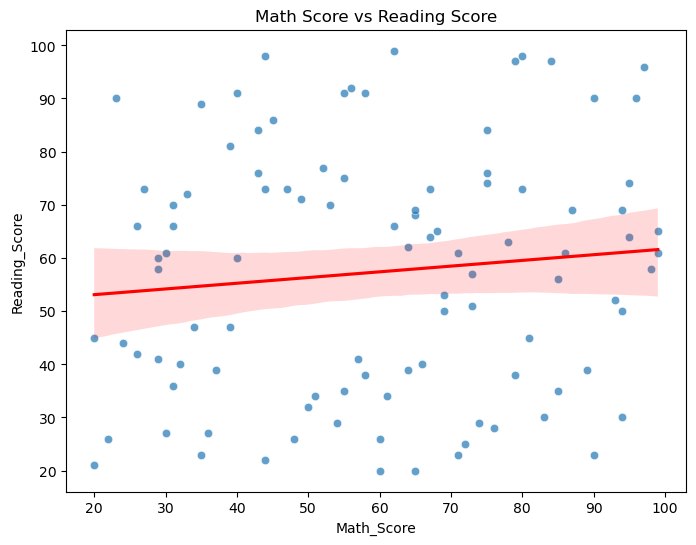

In [5]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Math_Score', y='Reading_Score', data=df, alpha=0.7)
sns.regplot(x='Math_Score', y='Reading_Score', data=df, scatter=False, color='red')
plt.title("Math Score vs Reading Score")
plt.show()

In [6]:
#Categorical vs Continuous
print("\n🔹 Categorical vs Continuous (Gender vs Math_Score)")
print(df.groupby("Gender")['Math_Score'].mean())


🔹 Categorical vs Continuous (Gender vs Math_Score)
Gender
Female    61.756098
Male      58.237288
Name: Math_Score, dtype: float64


In [7]:
male_scores = df[df['Gender']=='Male']['Math_Score']
female_scores = df[df['Gender']=='Female']['Math_Score']
t_stat, p_val = ttest_ind(male_scores, female_scores)
print(f"T-test: statistic={t_stat:.2f}, p-value={p_val:.4f}")

T-test: statistic=-0.76, p-value=0.4519


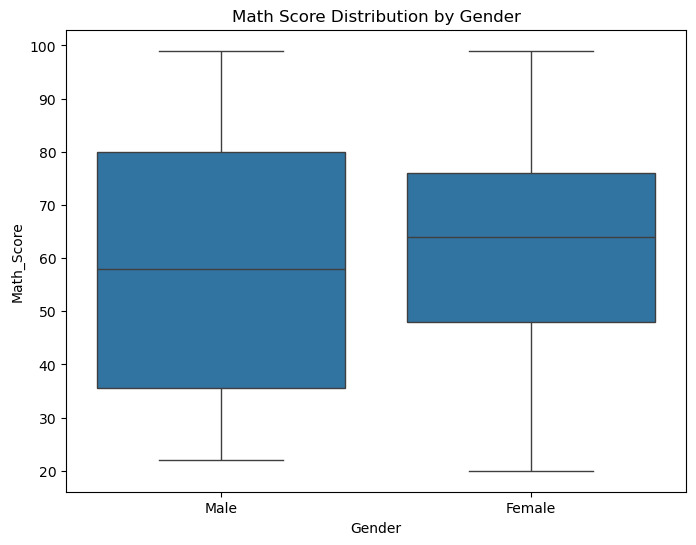

In [8]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Gender', y='Math_Score', data=df)
plt.title("Math Score Distribution by Gender")
plt.show()

In [9]:
# Categorical vs Categorical
print("\n🔹 Categorical vs Categorical (School Type vs High Achiever)")
ct = pd.crosstab(df['School_Type'], df['High_Achiever'])
print(ct)


🔹 Categorical vs Categorical (School Type vs High Achiever)
High_Achiever   0   1
School_Type          
Government     34  20
Private        30  16


In [11]:
chi2, p, dof, expected = chi2_contingency(ct)
print(f"Chi-square Test: chi2={chi2:.2f}, p-value={p:.4f}")



Chi-square Test: chi2=0.00, p-value=0.9800


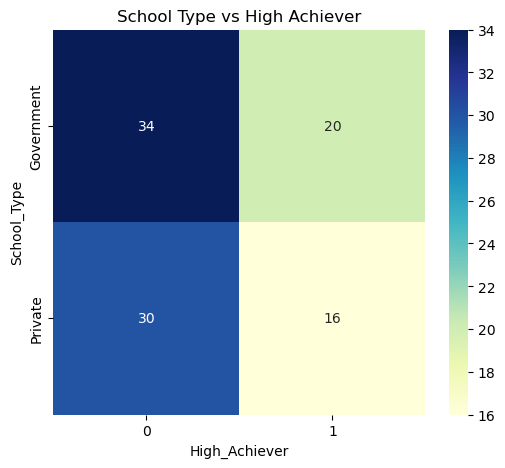

In [12]:
plt.figure(figsize=(6,5))
sns.heatmap(ct, annot=True, fmt="d", cmap="YlGnBu")
plt.title("School Type vs High Achiever")
plt.show()

# assignment

The dataset contains student-level academic performance and demographic details.
Columns include:

Gender (Male/Female) – Categorical

School_Type (Government/Private) – Categorical

Math_Score (0–100) – Continuous

Reading_Score (0–100) – Continuous

Science_Score (0–100) – Continuous

Study_Hours (1–10) – Continuous

High_Achiever (1 if Math_Score ≥ 70, else 0) – Categorical (binary)

Part A – Continuous vs Continuous

Plot a scatterplot of Math_Score vs Reading_Score.

Does there appear to be a positive correlation?

Compute the Pearson correlation coefficient between Math and Reading scores.

Interpret the strength and direction of the relationship.

Do students who spend more Study_Hours tend to perform better in Science_Score?

Part B – Categorical vs Continuous

Compare average Math_Score of Male and Female students.

Perform a t-test to check if the difference is statistically significant.

Create a boxplot to visualize the score distribution.

Compare Science_Score between students in Government vs Private schools.

Which group performs better on average?

Part C – Categorical vs Categorical

Create a crosstab between School_Type and High_Achiever.

What percentage of Private school students are high achievers compared to Government school students?

Perform a Chi-square test to check if there is an association between School_Type and High_Achiever.